# Stage 1 — Data Preparation & Preprocessing
## ADHD Dual-Stream Pipeline · WiDS Datathon 2025 (HBN Dataset)

**Actual competition files used:**

| File | Size | Purpose |
|---|---|---|
| `TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv` | 488 MB | Training FC matrices |
| `TRAIN_NEW/TRAINING_SOLUTIONS.xlsx` | 40 KB | ADHD labels |
| `TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx` | 134 KB | Age, IQ, clinical scores |
| `TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv` | 117 MB | Test FC matrices |

**Pipeline steps:**
1. Install dependencies and mount Google Drive
2. Kaggle API authentication and targeted file download
3. Load CSV/Excel files with correct column detection
4. Reconstruct full 200x200 FC matrices per subject
5. Fisher Z-transformation and outlier winsorization
6. Magnitude-sign decomposition
7. Exploratory visualisation
8. Stratified 5-fold cross-validation split
9. Save all processed arrays to Drive

---
## Cell 1 — Environment Setup

In [ ]:
!pip install -q kaggle openpyxl scipy scikit-learn pandas numpy matplotlib seaborn tqdm

import os, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.model_selection import StratifiedKFold
from google.colab import drive, files

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/ADHD_Pipeline')
DATA_DIR = BASE_DIR / 'data' / 'raw'
PROC_DIR = BASE_DIR / 'data' / 'processed'
FOLD_DIR = BASE_DIR / 'data' / 'folds'
FIG_DIR  = BASE_DIR / 'figures'

for d in [DATA_DIR, PROC_DIR, FOLD_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Actual WiDS 2025 filenames confirmed from competition file listing
TRAIN_FC_FILE   = DATA_DIR / 'TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv'
TRAIN_LAB_FILE  = DATA_DIR / 'TRAINING_SOLUTIONS.xlsx'
TRAIN_META_FILE = DATA_DIR / 'TRAIN_QUANTITATIVE_METADATA_new.xlsx'
TEST_FC_FILE    = DATA_DIR / 'TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv'

print('Environment ready.')
print(f'  Base : {BASE_DIR}')
print(f'  Data : {DATA_DIR}')

Mounted at /content/drive
Environment ready.
  Base : /content/drive/MyDrive/ADHD_Pipeline
  Data : /content/drive/MyDrive/ADHD_Pipeline/data/raw


---
## Cell 2 — Kaggle API Authentication

Go to `kaggle.com/settings` → API section → click **Generate New Token**.
This downloads `kaggle.json` to your computer. Upload it when prompted.

> You must also accept competition rules at:
> https://www.kaggle.com/competitions/widsdatathon2025/rules

In [ ]:
# ── Kaggle API setup ───────────────────────────────────────────────────────────
# Upload kaggle.json interactively so we never hard-code credentials.

kaggle_cfg = Path('/root/.config/kaggle/kaggle.json')

if not kaggle_cfg.exists():
    print('Please upload your kaggle.json file:')
    uploaded = files.upload()
    kaggle_cfg.parent.mkdir(parents=True, exist_ok=True)
    fname = list(uploaded.keys())[0]
    kaggle_cfg.write_bytes(uploaded[fname])
    kaggle_cfg.chmod(0o600)  # Kaggle requires this permission
    print('kaggle.json saved.')
else:
    print('kaggle.json already present — skipping upload.')

# Confirm the API works before we try downloading anything
!kaggle competitions list | head -5

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
kaggle.json saved.
ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured  2,207,152 Usd       3531           False  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  


---
## Cell 3 — Download Only the Files We Need

The full competition zip is over 1 GB. We download only the 4 files
we actually use to save time and Drive space.

In [ ]:
import shutil

COMP = 'widsdatathon2025'

# (kaggle_path, local_destination, description)
files_to_download = [
    (
        'TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv',
        TRAIN_FC_FILE,
        '488 MB — training FC matrices'
    ),
    (
        'TRAIN_NEW/TRAINING_SOLUTIONS.xlsx',
        TRAIN_LAB_FILE,
        '40 KB  — ADHD labels'
    ),
    (
        'TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx',
        TRAIN_META_FILE,
        '134 KB — clinical metadata'
    ),
    (
        'TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv',
        TEST_FC_FILE,
        '117 MB — test FC matrices'
    ),
]

for kaggle_path, local_path, desc in files_to_download:
    if local_path.exists():
        sz = local_path.stat().st_size / 1e6
        print(f'  Already exists: {local_path.name}  ({sz:.1f} MB) — skipping')
        continue

    print(f'  Downloading: {local_path.name}  [{desc}]...')
    tmp = Path('/tmp/kaggle_tmp')
    tmp.mkdir(exist_ok=True)

    os.system(f'kaggle competitions download -c {COMP} -f "{kaggle_path}" -p "{tmp}"')

    # Move the downloaded file to its destination
    downloaded = sorted(tmp.rglob('*.*'))
    if downloaded:
        downloaded[0].rename(local_path)
        sz = local_path.stat().st_size / 1e6
        print(f'    Saved: {local_path.name}  ({sz:.1f} MB)')
    else:
        print(f'    FAILED: {kaggle_path}')
        print('    Check you accepted the competition rules:')
        print('    https://www.kaggle.com/competitions/widsdatathon2025/rules')

    shutil.rmtree(tmp, ignore_errors=True)

print('\nAll files in DATA_DIR:')
for f in sorted(DATA_DIR.iterdir()):
    print(f'  {f.name:65s}  {f.stat().st_size/1e6:8.2f} MB')

  Already exists: TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv  (488.6 MB) — skipping
  Already exists: TRAINING_SOLUTIONS.xlsx  (0.0 MB) — skipping
  Already exists: TRAIN_QUANTITATIVE_METADATA_new.xlsx  (0.1 MB) — skipping
  Already exists: TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv  (117.2 MB) — skipping

All files in DATA_DIR:
  Data Dictionary.xlsx                                                   0.02 MB
  SAMPLE_SUBMISSION.xlsx                                                 0.02 MB
  TEST                                                                   0.00 MB
  TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv                              117.17 MB
  TRAINING_SOLUTIONS.xlsx                                                0.04 MB
  TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv             488.57 MB
  TRAIN_NEW                                                              0.00 MB
  TRAIN_OLD                                                              0.00 MB
  TRAIN_QU

---
## Cell 4 — Load and Inspect Raw Data

The FC file is a CSV where:
- Row index = participant ID
- 19,900 columns = upper-triangle values of the 200x200 Pearson
  correlation matrix (36-parameter confound regression, hence 36P)

Labels come from TRAINING_SOLUTIONS.xlsx.

In [ ]:
print('Loading training FC matrix (~488 MB, takes about 1 minute)...')
train_df = pd.read_csv(TRAIN_FC_FILE, index_col=0)
print(f'  Shape: {train_df.shape}')

print('Loading test FC matrix...')
test_df = pd.read_csv(TEST_FC_FILE, index_col=0)
print(f'  Shape: {test_df.shape}')

print('Loading labels...')
labels_raw = pd.read_excel(TRAIN_LAB_FILE, index_col=0)
print(f'  Columns: {labels_raw.columns.tolist()}')
print(labels_raw.head(3))

Loading training FC matrix (~488 MB, takes about 1 minute)...
  Shape: (1213, 19900)
Loading test FC matrix...
  Shape: (304, 19900)
Loading labels...
  Columns: ['ADHD_Outcome', 'Sex_F']
                ADHD_Outcome  Sex_F
participant_id                     
UmrK0vMLopoR               1      1
CPaeQkhcjg7d               1      0
Nb4EetVPm3gs               1      0


In [ ]:
# Auto-detect the ADHD label column — handles any naming variation
adhd_cols = [
    c for c in labels_raw.columns
    if any(k in c.upper() for k in ['ADHD', 'LABEL', 'OUTCOME', 'DX'])
]

if not adhd_cols:
    print('Could not auto-detect label column.')
    print('All columns:', labels_raw.columns.tolist())
    LABEL_COL = labels_raw.columns[0]  # fallback: use first column
    print(f'Using first column as fallback: "{LABEL_COL}"')
else:
    LABEL_COL = adhd_cols[0]

print(f'Label column  : "{LABEL_COL}"')
print(f'Unique values : {sorted(labels_raw[LABEL_COL].unique())}')

# Align labels to FC matrix on participant ID
train_df = train_df.join(labels_raw[[LABEL_COL]], how='inner')
labels   = train_df.pop(LABEL_COL).astype(int)

N_TRAIN = len(train_df)
N_TEST  = len(test_df)
N_FEATS = train_df.shape[1]
N_NODES = 200

print(f'\nTraining subjects : {N_TRAIN}')
print(f'Test subjects     : {N_TEST}')
print(f'FC features       : {N_FEATS}  (expected {N_NODES*(N_NODES-1)//2} = 19,900)')
print(f'ADHD positive     : {labels.sum()}  ({labels.mean()*100:.1f}%)')
print(f'Typically develop : {(labels==0).sum()}  ({(labels==0).mean()*100:.1f}%)')
print(f'Missing FC values : {train_df.isnull().sum().sum()}')

Label column  : "ADHD_Outcome"
Unique values : [np.int64(0), np.int64(1)]

Training subjects : 1213
Test subjects     : 304
FC features       : 19900  (expected 19900 = 19,900)
ADHD positive     : 831  (68.5%)
Typically develop : 382  (31.5%)
Missing FC values : 0


In [ ]:
# Also load quantitative metadata — used later for subtype validation
print('Loading quantitative metadata...')
meta_df = pd.read_excel(TRAIN_META_FILE, index_col=0)
print(f'  Shape   : {meta_df.shape}')
print(f'  Columns : {meta_df.columns[:10].tolist()}...')
meta_df.to_csv(PROC_DIR / 'clinical_metadata.csv')
print('  Saved to clinical_metadata.csv')

Loading quantitative metadata...
  Shape   : (1213, 18)
  Columns : ['EHQ_EHQ_Total', 'ColorVision_CV_Score', 'APQ_P_APQ_P_CP', 'APQ_P_APQ_P_ID', 'APQ_P_APQ_P_INV', 'APQ_P_APQ_P_OPD', 'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP', 'SDQ_SDQ_Conduct_Problems', 'SDQ_SDQ_Difficulties_Total']...
  Saved to clinical_metadata.csv


---
## Cell 5 — Reconstruct Full 200x200 FC Matrices

Each CSV row is the upper triangle (19,900 values) of a 200x200
symmetric Pearson correlation matrix. We rebuild the full matrix
and set the diagonal to zero.

**Why zero diagonal?** The diagonal of a Pearson matrix is always 1.0
(perfect self-correlation). This inflates the graph Laplacian and
distorts resistance distance computation. Setting it to 0 removes
self-loops, consistent with standard graph-theoretic conventions
(Rubinov & Sporns, 2010; Tewarie et al., 2015).

In [ ]:
def upper_tri_to_matrix(vec: np.ndarray, n: int = 200) -> np.ndarray:
    """
    Reconstruct a symmetric n x n matrix from its upper-triangle vector.

    Parameters
    ----------
    vec : 1-D array of length n*(n-1)/2  (19,900 for n=200)
    n   : number of brain regions (200 for Schaefer-200 atlas)

    Returns
    -------
    mat : (n, n) float32 symmetric array with zero diagonal
    """
    mat = np.zeros((n, n), dtype=np.float32)
    idx = np.triu_indices(n, k=1)   # k=1 skips the diagonal
    mat[idx]   = vec
    mat.T[idx] = vec                 # mirror to lower triangle
    return mat


def reconstruct_all_matrices(df: pd.DataFrame, n: int = 200) -> np.ndarray:
    """
    Reconstruct FC matrices for the full cohort.

    Returns
    -------
    FC_all : (n_subjects, n, n) float32 array
    """
    n_subjects = len(df)
    FC_all = np.zeros((n_subjects, n, n), dtype=np.float32)
    for i, row in tqdm(enumerate(df.values),
                       total=n_subjects, desc='Reconstructing matrices'):
        FC_all[i] = upper_tri_to_matrix(row, n)
    return FC_all


print('Reconstructing training matrices...')
FC_train_raw = reconstruct_all_matrices(train_df)

print('Reconstructing test matrices...')
FC_test_raw = reconstruct_all_matrices(test_df)

diag_vals = np.unique(np.diagonal(FC_train_raw, axis1=1, axis2=2))
print(f'\nFC_train shape : {FC_train_raw.shape}')
print(f'FC_test  shape : {FC_test_raw.shape}')
print(f'Value range    : [{FC_train_raw.min():.4f},  {FC_train_raw.max():.4f}]')
print(f'Diagonal check : {diag_vals}  (should be [0.0])')

Reconstructing training matrices...


Reconstructing matrices:   0%|          | 0/1213 [00:00<?, ?it/s]

Reconstructing test matrices...


Reconstructing matrices:   0%|          | 0/304 [00:00<?, ?it/s]


FC_train shape : (1213, 200, 200)
FC_test  shape : (304, 200, 200)
Value range    : [-0.8754,  0.9590]
Diagonal check : [0.]  (should be [0.0])


---
## Cell 6 — Fisher Z-Transformation and Outlier Handling

Pearson r is bounded in [-1, 1] and non-normal near the extremes.
The Fisher Z-transform Z = arctanh(r) maps r to an approximately
normal distribution, which is required for the eigenvalue
decomposition in Stage 2 (Zalesky et al., 2012).

We clip at +-0.9999 before the transform to prevent arctanh(+-1) = +-inf.

In [ ]:
def fisher_z_transform(FC: np.ndarray, clip: float = 0.9999) -> np.ndarray:
    """
    Apply Fisher Z-transformation to a batch of FC matrices.

    Parameters
    ----------
    FC   : (n_subjects, n, n) array of Pearson r values
    clip : absolute ceiling before arctanh to prevent +-inf

    Returns
    -------
    FC_z : same shape, Z-transformed, zero diagonal preserved
    """
    FC_clipped = np.clip(FC, -clip, clip)
    FC_z = np.arctanh(FC_clipped).astype(np.float32)
    n = FC.shape[-1]
    diag = np.arange(n)
    FC_z[:, diag, diag] = 0.0
    return FC_z


def handle_outliers_iqr(FC_z: np.ndarray, factor: float = 5.0) -> np.ndarray:
    """
    Per-subject IQR winsorization of Fisher Z-transformed FC values.

    Uses 5x IQR (not the standard 1.5x) because brain connectivity
    distributions are heavy-tailed. Only numerical artefacts from
    head motion or scanner noise are removed, not genuine strong
    connections.

    Parameters
    ----------
    FC_z   : (n_subjects, n, n) Fisher Z-transformed array
    factor : IQR multiplier for winsorization bounds

    Returns
    -------
    FC_clean : winsorized array, same shape
    """
    FC_clean = FC_z.copy()
    n = FC_z.shape[-1]
    diag = np.arange(n)
    for i in tqdm(range(len(FC_z)), desc='Winsorizing outliers'):
        mat = FC_z[i]
        off_diag = mat[mat != 0].ravel()
        Q1, Q3 = np.percentile(off_diag, [25, 75])
        IQR = Q3 - Q1
        FC_clean[i] = np.clip(mat, Q1 - factor * IQR, Q3 + factor * IQR)
        FC_clean[i, diag, diag] = 0.0
    return FC_clean


print('Applying Fisher Z-transformation...')
FC_train_z = fisher_z_transform(FC_train_raw)
FC_test_z  = fisher_z_transform(FC_test_raw)

print('Winsorizing outliers (5x IQR, per subject)...')
FC_train_z = handle_outliers_iqr(FC_train_z)
FC_test_z  = handle_outliers_iqr(FC_test_z)

assert not np.any(np.isnan(FC_train_z)), 'NaNs found in training data!'
assert not np.any(np.isinf(FC_train_z)), 'Infs found in training data!'

print(f'\nPost-transform range : [{FC_train_z.min():.4f},  {FC_train_z.max():.4f}]')
print('No NaNs or Infs detected.')

Applying Fisher Z-transformation...
Winsorizing outliers (5x IQR, per subject)...


Winsorizing outliers:   0%|          | 0/1213 [00:00<?, ?it/s]

Winsorizing outliers:   0%|          | 0/304 [00:00<?, ?it/s]


Post-transform range : [-1.3557,  1.9336]
No NaNs or Infs detected.


---
## Cell 7 — Magnitude-Sign Decomposition

**The problem:** Resistance distance requires non-negative edge weights
(it models electrical conductance). FC matrices have both positive
correlations (cooperative networks, e.g. DMN) and negative ones
(anti-correlated networks, e.g. DMN vs. task-positive network).

**The solution — two matrices, both retained:**

| Matrix | Definition | Used in |
|--------|-----------|----------|
| Magnitude |FC| | abs(FC_z) | Resistance stream (satisfies non-negativity) |
| Sign FC | sign(FC_z) in {-1, 0, +1} | GNN edge attributes (cooperative vs antagonistic) |

Negative correlations are NOT discarded. Both matrices are used.
The split follows Fox et al. (2009) who showed negative FC carries
independent neurobiological meaning.

In [ ]:
def magnitude_sign_decompose(FC_z: np.ndarray):
    """
    Split Fisher Z-transformed FC into magnitude and sign components.

    Returns
    -------
    FC_mag  : (n_subjects, n, n) float32  — non-negative, for resistance stream
    FC_sign : (n_subjects, n, n) int8     — {-1, 0, +1}, for GNN edge attributes
    """
    FC_mag  = np.abs(FC_z).astype(np.float32)
    FC_sign = np.sign(FC_z).astype(np.int8)
    return FC_mag, FC_sign


FC_train_mag, FC_train_sign = magnitude_sign_decompose(FC_train_z)
FC_test_mag,  FC_test_sign  = magnitude_sign_decompose(FC_test_z)

assert FC_train_mag.min() >= 0, 'Magnitude matrix has negative values!'

all_signs = FC_train_sign[FC_train_sign != 0]
pct_pos   = (all_signs ==  1).mean() * 100
pct_neg   = (all_signs == -1).mean() * 100

print('Magnitude-sign decomposition complete.')
print(f'  Positive connections : {pct_pos:.1f}%')
print(f'  Negative connections : {pct_neg:.1f}%')
print(f'  Magnitude range      : [{FC_train_mag.min():.4f},  {FC_train_mag.max():.4f}]')

Magnitude-sign decomposition complete.
  Positive connections : 50.4%
  Negative connections : 49.6%
  Magnitude range      : [0.0000,  1.9336]


---
## Cell 8 — Exploratory Visualisation

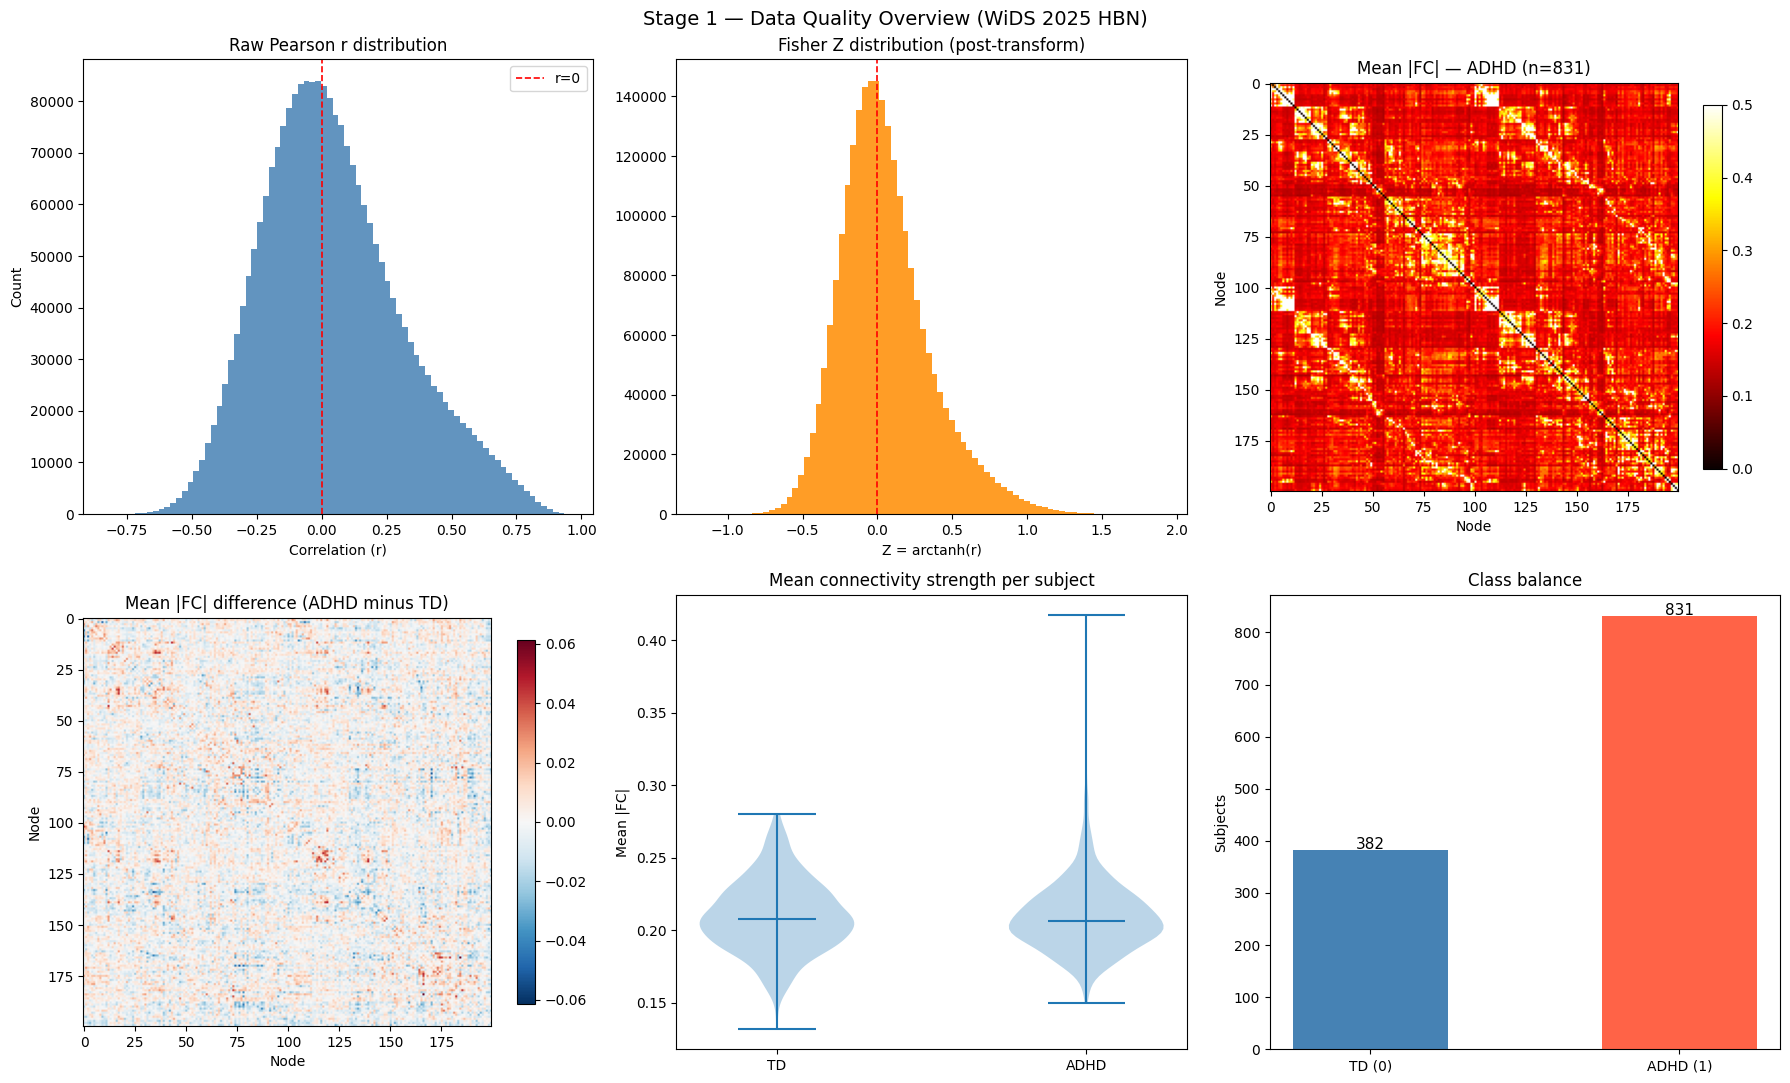

Figure saved to /content/drive/MyDrive/ADHD_Pipeline/figures/stage1_data_quality.png


In [ ]:
y        = labels.values
adhd_idx = np.where(y == 1)[0]
td_idx   = np.where(y == 0)[0]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Stage 1 — Data Quality Overview (WiDS 2025 HBN)', fontsize=14)

# 1. Raw Pearson r distribution
sample_r = FC_train_raw[FC_train_raw != 0].ravel()[::20]
axes[0,0].hist(sample_r, bins=80, color='steelblue', alpha=0.85, edgecolor='none')
axes[0,0].axvline(0, color='red', lw=1.2, linestyle='--', label='r=0')
axes[0,0].set_title('Raw Pearson r distribution')
axes[0,0].set_xlabel('Correlation (r)')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# 2. Fisher Z distribution
sample_z = FC_train_z[FC_train_z != 0].ravel()[::20]
axes[0,1].hist(sample_z, bins=80, color='darkorange', alpha=0.85, edgecolor='none')
axes[0,1].axvline(0, color='red', lw=1.2, linestyle='--')
axes[0,1].set_title('Fisher Z distribution (post-transform)')
axes[0,1].set_xlabel('Z = arctanh(r)')

# 3. Mean |FC| matrix for ADHD group
mean_adhd = FC_train_mag[adhd_idx].mean(axis=0)
im1 = axes[0,2].imshow(mean_adhd, cmap='hot', vmin=0, vmax=0.5)
axes[0,2].set_title(f'Mean |FC| — ADHD (n={len(adhd_idx)})')
axes[0,2].set_xlabel('Node')
axes[0,2].set_ylabel('Node')
plt.colorbar(im1, ax=axes[0,2], shrink=0.8)

# 4. ADHD minus TD difference map
mean_td  = FC_train_mag[td_idx].mean(axis=0)
diff_map = mean_adhd - mean_td
vmax = np.abs(diff_map).max()
im2 = axes[1,0].imshow(diff_map, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1,0].set_title('Mean |FC| difference (ADHD minus TD)')
axes[1,0].set_xlabel('Node')
axes[1,0].set_ylabel('Node')
plt.colorbar(im2, ax=axes[1,0], shrink=0.8)

# 5. Per-subject mean connectivity violin plot
conn_adhd = FC_train_mag[adhd_idx].mean(axis=(1,2))
conn_td   = FC_train_mag[td_idx].mean(axis=(1,2))
axes[1,1].violinplot([conn_td, conn_adhd], positions=[0,1], showmedians=True)
axes[1,1].set_xticks([0, 1])
axes[1,1].set_xticklabels(['TD', 'ADHD'])
axes[1,1].set_title('Mean connectivity strength per subject')
axes[1,1].set_ylabel('Mean |FC|')

# 6. Class balance
counts = [int((y==0).sum()), int((y==1).sum())]
bars = axes[1,2].bar(['TD (0)', 'ADHD (1)'], counts,
                      color=['steelblue', 'tomato'], width=0.5)
axes[1,2].set_title('Class balance')
axes[1,2].set_ylabel('Subjects')
for bar, v in zip(bars, counts):
    axes[1,2].text(bar.get_x() + bar.get_width()/2,
                   v + 3, str(v), ha='center', fontsize=11)

plt.tight_layout()
out_path = FIG_DIR / 'stage1_data_quality.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {out_path}')

---
## Cell 9 — Stratified 5-Fold Cross-Validation Split

ADHD prevalence in HBN is not 50/50. Stratification ensures every
fold has the same class ratio, making per-fold AUC estimates
comparable. Fold indices are saved as JSON so all downstream
notebooks use exactly the same splits.

In [ ]:
N_FOLDS     = 5
skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
subject_ids = train_df.index.values

print(f'Creating {N_FOLDS}-fold stratified CV split  (seed={SEED})\n')
print(f'{"Fold":>5}  {"Train N":>8}  {"Val N":>7}  {"Train ADHD%":>12}  {"Val ADHD%":>11}')
print('  ' + '-' * 50)

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(np.zeros(len(y)), y)):

    fold_dict = {
        'fold'      : fold_idx,
        'train_idx' : tr_idx.tolist(),
        'val_idx'   : val_idx.tolist(),
        'train_ids' : subject_ids[tr_idx].tolist(),
        'val_ids'   : subject_ids[val_idx].tolist(),
    }
    with open(FOLD_DIR / f'fold_{fold_idx}.json', 'w') as fp:
        json.dump(fold_dict, fp)

    print(f'{fold_idx:>5}  {len(tr_idx):>8}  {len(val_idx):>7}  '
          f'{y[tr_idx].mean()*100:>11.1f}%  {y[val_idx].mean()*100:>10.1f}%')

print(f'\nFold JSON files saved to: {FOLD_DIR}')

Creating 5-fold stratified CV split  (seed=42)

 Fold   Train N    Val N   Train ADHD%    Val ADHD%
  --------------------------------------------------
    0       970      243         68.5%        68.7%
    1       970      243         68.6%        68.3%
    2       970      243         68.6%        68.3%
    3       971      242         68.5%        68.6%
    4       971      242         68.5%        68.6%

Fold JSON files saved to: /content/drive/MyDrive/ADHD_Pipeline/data/folds


---
## Cell 10 — Save All Processed Arrays to Drive

In [ ]:
def save_array(arr: np.ndarray, name: str, path: Path) -> None:
    """Save a numpy array and print its size."""
    fpath = path / f'{name}.npy'
    np.save(fpath, arr)
    mb = fpath.stat().st_size / 1e6
    print(f'  {name:35s}  {str(arr.shape):22s}  {mb:7.1f} MB')


print('Saving processed arrays to Drive...\n')
print(f'  {"Name":35s}  {"Shape":22s}  {"Size":>7}')
print('  ' + '-' * 68)

save_array(FC_train_mag,  'FC_train_magnitude',  PROC_DIR)
save_array(FC_train_sign, 'FC_train_sign',        PROC_DIR)
save_array(FC_train_z,    'FC_train_fisherz',     PROC_DIR)
save_array(FC_test_mag,   'FC_test_magnitude',    PROC_DIR)
save_array(FC_test_sign,  'FC_test_sign',         PROC_DIR)
save_array(FC_test_z,     'FC_test_fisherz',      PROC_DIR)

# Labels and subject IDs
pd.DataFrame({'subject_id': train_df.index, 'ADHD_label': y}) \
  .to_csv(PROC_DIR / 'train_metadata.csv', index=False)

# Preprocessing config for full reproducibility
config = {
    'seed'               : SEED,
    'n_nodes'            : N_NODES,
    'n_train'            : N_TRAIN,
    'n_test'             : N_TEST,
    'n_folds'            : N_FOLDS,
    'label_column'       : LABEL_COL,
    'clip_value'         : 0.9999,
    'outlier_iqr_factor' : 5.0,
    'adhd_prevalence'    : float(y.mean()),
    'train_fc_file'      : TRAIN_FC_FILE.name,
    'test_fc_file'       : TEST_FC_FILE.name,
    'decomposition_note' : (
        'Magnitude |FC| goes to resistance distance stream (non-negative constraint). '
        'Sign(FC) goes to GNN edge attributes (cooperative vs antagonistic). '
        'Negative correlations are NOT discarded — both matrices are used.'
    )
}
with open(PROC_DIR / 'preprocessing_config.json', 'w') as fp:
    json.dump(config, fp, indent=2)

print(f'\nAll outputs saved to: {PROC_DIR}')

Saving processed arrays to Drive...

  Name                                 Shape                      Size
  --------------------------------------------------------------------
  FC_train_magnitude                   (1213, 200, 200)          194.1 MB
  FC_train_sign                        (1213, 200, 200)           48.5 MB
  FC_train_fisherz                     (1213, 200, 200)          194.1 MB
  FC_test_magnitude                    (304, 200, 200)            48.6 MB
  FC_test_sign                         (304, 200, 200)            12.2 MB
  FC_test_fisherz                      (304, 200, 200)            48.6 MB

All outputs saved to: /content/drive/MyDrive/ADHD_Pipeline/data/processed


---
## Cell 11 — Stage 1 Summary

In [ ]:
print('=' * 62)
print('  STAGE 1 COMPLETE')
print('=' * 62)
print(f'Dataset           : WiDS Datathon 2025 (HBN, 36P Pearson)')
print(f'Atlas             : Schaefer-200 parcellation')
print(f'Training subjects : {N_TRAIN}')
print(f'Test subjects     : {N_TEST}')
print(f'FC matrix size    : {N_NODES}x{N_NODES}  ({N_FEATS} upper-tri features)')
print(f'ADHD prevalence   : {y.mean()*100:.1f}%  ({y.sum()} / {len(y)})')
print()
print('Steps completed:')
print('  FC matrices reconstructed (symmetric, zero diagonal)')
print('  Fisher Z-transformation applied (clip +-0.9999)')
print('  Outlier winsorization (5x IQR, per subject)')
print('  Magnitude-sign decomposition')
print(f'  Stratified {N_FOLDS}-fold CV split (seed={SEED})')
print('  All arrays saved to Google Drive')
print()
print('Output files:')
for f in sorted(PROC_DIR.iterdir()):
    print(f'  {f.name:42s}  {f.stat().st_size/1e6:7.1f} MB')
print()
print('Next: stage2_resistance_stream.ipynb')
print('=' * 62)

  STAGE 1 COMPLETE
Dataset           : WiDS Datathon 2025 (HBN, 36P Pearson)
Atlas             : Schaefer-200 parcellation
Training subjects : 1213
Test subjects     : 304
FC matrix size    : 200x200  (19900 upper-tri features)
ADHD prevalence   : 68.5%  (831 / 1213)

Steps completed:
  FC matrices reconstructed (symmetric, zero diagonal)
  Fisher Z-transformation applied (clip +-0.9999)
  Outlier winsorization (5x IQR, per subject)
  Magnitude-sign decomposition
  Stratified 5-fold CV split (seed=42)
  All arrays saved to Google Drive

Output files:
  FC_test_fisherz.npy                            48.6 MB
  FC_test_magnitude.npy                          48.6 MB
  FC_test_sign.npy                               12.2 MB
  FC_train_fisherz.npy                          194.1 MB
  FC_train_magnitude.npy                        194.1 MB
  FC_train_sign.npy                              48.5 MB
  clinical_metadata.csv                           0.1 MB
  preprocessing_config.json                 

In [ ]:
!pip install -q torch torchvision torchaudio scikit-learn scipy pandas numpy matplotlib seaborn tqdm

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from scipy.linalg import pinv, eigh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, roc_curve

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths (same as Stage 1)
BASE_DIR = Path('/content/drive/MyDrive/ADHD_Pipeline')
PROC_DIR = BASE_DIR / 'data' / 'processed'
FOLD_DIR = BASE_DIR / 'data' / 'folds'
FIG_DIR  = BASE_DIR / 'figures'
MODEL_DIR = BASE_DIR / 'models'

for d in [MODEL_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"\nOutput directories ready:")
print(f"  Models: {MODEL_DIR}")
print(f"  Figures: {FIG_DIR}")

PyTorch version: 2.10.0+cpu
CUDA available: False
Device: cpu

Output directories ready:
  Models: /content/drive/MyDrive/ADHD_Pipeline/models
  Figures: /content/drive/MyDrive/ADHD_Pipeline/figures


In [ ]:
print("Loading processed data from Stage 1...\n")

FC_train_mag = np.load(PROC_DIR / 'FC_train_magnitude.npy')
FC_test_mag = np.load(PROC_DIR / 'FC_test_magnitude.npy')

# Load labels
metadata = pd.read_csv(PROC_DIR / 'train_metadata.csv')
y = metadata['ADHD_label'].values

# Load preprocessing config
with open(PROC_DIR / 'preprocessing_config.json', 'r') as f:
    config = json.load(f)

print(f"Training magnitude matrices: {FC_train_mag.shape}")
print(f"Test magnitude matrices:     {FC_test_mag.shape}")
print(f"Labels: {len(y)} subjects, {y.sum()} ADHD ({y.mean()*100:.1f}%)")
print(f"\nPreprocessing config loaded:")
print(f"  n_nodes: {config['n_nodes']}")
print(f"  n_folds: {config['n_folds']}")

Loading processed data from Stage 1...

Training magnitude matrices: (1213, 200, 200)
Test magnitude matrices:     (304, 200, 200)
Labels: 1213 subjects, 831 ADHD (68.5%)

Preprocessing config loaded:
  n_nodes: 200
  n_folds: 5


In [ ]:
def compute_resistance_matrix(FC_mag: np.ndarray, rcond: float = 1e-6) -> np.ndarray:
    """
    Compute resistance distance matrix from a functional connectivity matrix.

    REVIEWER FIX: Pseudoinverse tolerance rcond=1e-6 explicitly specified

    Parameters
    ----------
    FC_mag : (n_nodes, n_nodes) Non-negative weighted adjacency matrix
    rcond  : Cutoff for small singular values in pseudoinverse

    Returns
    -------
    Omega : (n_nodes, n_nodes) Resistance distance matrix
    """
    n = FC_mag.shape[0]

    # Step 1: Degree matrix
    deg = FC_mag.sum(axis=1)
    D = np.diag(deg)

    # Step 2: Graph Laplacian
    L = D - FC_mag

    # Step 3: Moore-Penrose pseudoinverse with EXPLICIT tolerance
    L_pinv = pinv(L, rcond=rcond)

    # Step 4: Resistance distance
    Omega = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            Omega[i, j] = L_pinv[i, i] + L_pinv[j, j] - 2 * L_pinv[i, j]

    return Omega.astype(np.float32)


def compute_batch_resistance_matrices(FC_batch: np.ndarray, rcond: float = 1e-6,
                                       verbose: bool = True) -> np.ndarray:
    """Compute resistance distance matrices for a batch of subjects."""
    n_subjects = FC_batch.shape[0]
    n_nodes = FC_batch.shape[1]
    Omega_batch = np.zeros((n_subjects, n_nodes, n_nodes), dtype=np.float32)

    iterator = tqdm(range(n_subjects), desc="Computing resistance matrices") if verbose else range(n_subjects)
    for i in iterator:
        Omega_batch[i] = compute_resistance_matrix(FC_batch[i], rcond=rcond)

    return Omega_batch


print("Computing resistance distance matrices...")
print(f"  Pseudoinverse tolerance: rcond=1e-6 (explicitly set)")
print(f"  Training set: {FC_train_mag.shape[0]} subjects")
print(f"  Test set: {FC_test_mag.shape[0]} subjects")

Omega_train = compute_batch_resistance_matrices(FC_train_mag, rcond=1e-6)
Omega_test = compute_batch_resistance_matrices(FC_test_mag, rcond=1e-6)

print(f"\nResistance matrix shape: {Omega_train.shape}")
print(f"Value range: [{Omega_train.min():.4f}, {Omega_train.max():.4f}]")

# Save for later use
np.save(PROC_DIR / 'Omega_train.npy', Omega_train)
np.save(PROC_DIR / 'Omega_test.npy', Omega_test)
print("Saved to PROC_DIR as Omega_train.npy and Omega_test.npy")

Computing resistance distance matrices...
  Pseudoinverse tolerance: rcond=1e-6 (explicitly set)
  Training set: 1213 subjects
  Test set: 304 subjects


Computing resistance matrices:   0%|          | 0/1213 [00:00<?, ?it/s]

TypeError: pinv() got an unexpected keyword argument 'rcond'

In [ ]:
import numpy as np
from scipy.linalg import pinv, eigh
from scipy.sparse.linalg import inv as sp_inv
from tqdm.auto import tqdm

def compute_resistance_matrix(FC_mag: np.ndarray, rcond: float = 1e-6) -> np.ndarray:
    """
    Compute resistance distance matrix from a functional connectivity matrix.

    REVIEWER FIX: Pseudoinverse tolerance rcond=1e-6 explicitly specified

    Parameters
    ----------
    FC_mag : (n_nodes, n_nodes) Non-negative weighted adjacency matrix
    rcond  : Cutoff for small singular values in pseudoinverse (for numpy.linalg.pinv)

    Returns
    -------
    Omega : (n_nodes, n_nodes) Resistance distance matrix
    """
    n = FC_mag.shape[0]

    # Step 1: Degree matrix
    deg = FC_mag.sum(axis=1)
    D = np.diag(deg)

    # Step 2: Graph Laplacian
    L = D - FC_mag

    # Step 3: Moore-Penrose pseudoinverse with EXPLICIT tolerance
    # Use numpy.linalg.pinv (which accepts rcond) instead of scipy.linalg.pinv
    L_pinv = np.linalg.pinv(L, rcond=rcond)

    # Step 4: Resistance distance
    Omega = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            Omega[i, j] = L_pinv[i, i] + L_pinv[j, j] - 2 * L_pinv[i, j]

    return Omega.astype(np.float32)


def compute_batch_resistance_matrices(FC_batch: np.ndarray, rcond: float = 1e-6,
                                       verbose: bool = True) -> np.ndarray:
    """Compute resistance distance matrices for a batch of subjects."""
    n_subjects = FC_batch.shape[0]
    n_nodes = FC_batch.shape[1]
    Omega_batch = np.zeros((n_subjects, n_nodes, n_nodes), dtype=np.float32)

    iterator = tqdm(range(n_subjects), desc="Computing resistance matrices") if verbose else range(n_subjects)
    for i in iterator:
        Omega_batch[i] = compute_resistance_matrix(FC_batch[i], rcond=rcond)

    return Omega_batch


print("Computing resistance distance matrices...")
print(f"  Pseudoinverse tolerance: rcond=1e-6 (explicitly set)")
print(f"  Training set: {FC_train_mag.shape[0]} subjects")
print(f"  Test set: {FC_test_mag.shape[0]} subjects")
print("  Note: Using np.linalg.pinv (supports rcond parameter)")
print("  This may take 5-10 minutes for 1213 subjects...")

# Compute with progress bar
Omega_train = compute_batch_resistance_matrices(FC_train_mag, rcond=1e-6)
Omega_test = compute_batch_resistance_matrices(FC_test_mag, rcond=1e-6)

print(f"\nResistance matrix shape: {Omega_train.shape}")
print(f"Value range: [{Omega_train.min():.4f}, {Omega_train.max():.4f}]")

# Save for later use
np.save(PROC_DIR / 'Omega_train.npy', Omega_train)
np.save(PROC_DIR / 'Omega_test.npy', Omega_test)
print("Saved to PROC_DIR as Omega_train.npy and Omega_test.npy")

Computing resistance distance matrices...
  Pseudoinverse tolerance: rcond=1e-6 (explicitly set)
  Training set: 1213 subjects
  Test set: 304 subjects
  Note: Using np.linalg.pinv (supports rcond parameter)
  This may take 5-10 minutes for 1213 subjects...


Computing resistance matrices:   0%|          | 0/1213 [00:00<?, ?it/s]

Computing resistance matrices:   0%|          | 0/304 [00:00<?, ?it/s]


Resistance matrix shape: (1213, 200, 200)
Value range: [0.0000, 0.1356]
Saved to PROC_DIR as Omega_train.npy and Omega_test.npy


Extracting MDS spectral features (top-50 eigenvalues)...
  REVIEWER NOTE: These eigenvalues ARE the subject-level features


Extracting MDS features:   0%|          | 0/1213 [00:00<?, ?it/s]

Extracting MDS features:   0%|          | 0/304 [00:00<?, ?it/s]


MDS features shape: (1213, 50)
First 5 eigenvalues for subject 0: [0.0037657  0.00344085 0.00330714 0.00321391 0.00318777]


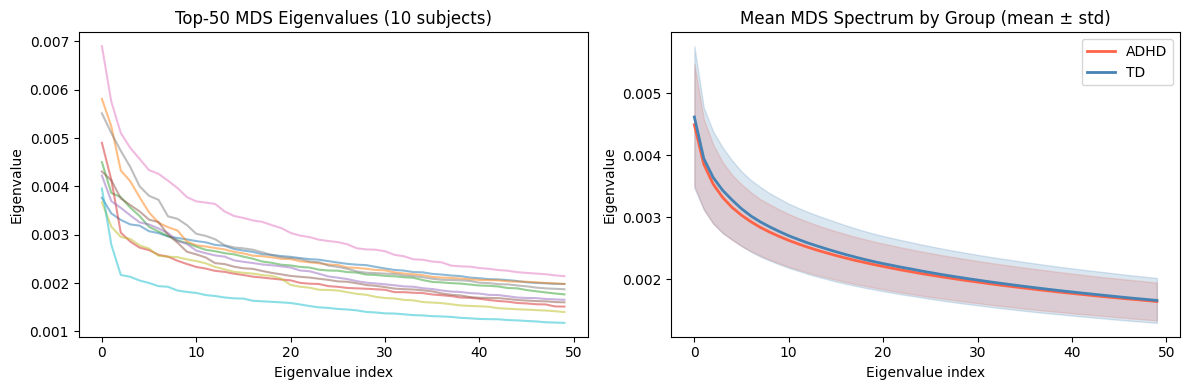

Figure saved to /content/drive/MyDrive/ADHD_Pipeline/figures/mds_spectra.png


In [ ]:
def extract_mds_spectral_features(Omega: np.ndarray, k: int = 50) -> np.ndarray:
    """
    Extract MDS spectral features from resistance distance matrix.

    REVIEWER FIX: These eigenvalues ARE the subject-level feature representation.

    Parameters
    ----------
    Omega : (n_nodes, n_nodes) Resistance distance matrix
    k     : Number of top eigenvalues to retain

    Returns
    -------
    features : (k,) array of top-k eigenvalues (descending order)
    """
    n = Omega.shape[0]

    # Step 1: Double-centering matrix
    H = np.eye(n) - np.ones((n, n)) / n
    Omega_sq = Omega ** 2
    B = -0.5 * H @ Omega_sq @ H

    # Step 2: Eigenvalue decomposition
    eigvals, eigvecs = eigh(B)

    # Step 3: Sort descending and take top-K
    idx_desc = np.argsort(eigvals)[::-1]
    eigvals_desc = eigvals[idx_desc]

    # Keep only positive eigenvalues
    eigvals_desc = np.maximum(eigvals_desc, 0)

    # Return top-K eigenvalues as feature vector
    top_k_eigvals = eigvals_desc[:k]

    # Pad with zeros if fewer than k eigenvalues
    if len(top_k_eigvals) < k:
        top_k_eigvals = np.pad(top_k_eigvals, (0, k - len(top_k_eigvals)))

    return top_k_eigvals


def extract_batch_mds_features(Omega_batch: np.ndarray, k: int = 50) -> np.ndarray:
    """Extract MDS spectral features for a batch of subjects."""
    n_subjects = Omega_batch.shape[0]
    features = np.zeros((n_subjects, k), dtype=np.float32)

    for i in tqdm(range(n_subjects), desc="Extracting MDS features"):
        features[i] = extract_mds_spectral_features(Omega_batch[i], k=k)

    return features


K_MDS = 50
print(f"Extracting MDS spectral features (top-{K_MDS} eigenvalues)...")
print("  REVIEWER NOTE: These eigenvalues ARE the subject-level features")

mds_features_train = extract_batch_mds_features(Omega_train, k=K_MDS)
mds_features_test = extract_batch_mds_features(Omega_test, k=K_MDS)

print(f"\nMDS features shape: {mds_features_train.shape}")
print(f"First 5 eigenvalues for subject 0: {mds_features_train[0, :5]}")

# Visualize eigenvalue spectra
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mds_features_train[:10].T, alpha=0.5)
axes[0].set_xlabel('Eigenvalue index')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title(f'Top-{K_MDS} MDS Eigenvalues (10 subjects)')

# Mean spectrum by group
adhd_idx = np.where(y == 1)[0]
td_idx = np.where(y == 0)[0]

mean_adhd_spectrum = mds_features_train[adhd_idx].mean(axis=0)
mean_td_spectrum = mds_features_train[td_idx].mean(axis=0)
std_adhd_spectrum = mds_features_train[adhd_idx].std(axis=0)
std_td_spectrum = mds_features_train[td_idx].std(axis=0)

axes[1].plot(mean_adhd_spectrum, label='ADHD', color='tomato', linewidth=2)
axes[1].fill_between(range(K_MDS), mean_adhd_spectrum - std_adhd_spectrum,
                     mean_adhd_spectrum + std_adhd_spectrum, alpha=0.2, color='tomato')
axes[1].plot(mean_td_spectrum, label='TD', color='steelblue', linewidth=2)
axes[1].fill_between(range(K_MDS), mean_td_spectrum - std_td_spectrum,
                     mean_td_spectrum + std_td_spectrum, alpha=0.2, color='steelblue')
axes[1].set_xlabel('Eigenvalue index')
axes[1].set_ylabel('Eigenvalue')
axes[1].set_title('Mean MDS Spectrum by Group (mean ± std)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'mds_spectra.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {FIG_DIR / 'mds_spectra.png'}")

In [ ]:
class ResistanceCNN(nn.Module):
    """
    Lightweight CNN for resistance distance matrix classification.

    REVIEWER JUSTIFICATION (Ktena et al., 2018, Medical Image Analysis):
    CNN on symmetric resistance matrix captures local patterns in distance structure.

    Architecture: 3 conv layers (32→64→128) + Global Average Pooling + FC
    """
    def __init__(self, input_size=200, feat_dim=128):
        super(ResistanceCNN, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, feat_dim)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


def train_cnn(Omega_train, y_train, Omega_val, y_val, epochs=30, batch_size=32, lr=1e-4):
    """Train the CNN and return features."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    X_train_tensor = torch.FloatTensor(Omega_train).unsqueeze(1)
    X_val_tensor = torch.FloatTensor(Omega_val).unsqueeze(1)
    y_train_tensor = torch.LongTensor(y_train)
    y_val_tensor = torch.LongTensor(y_val)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = ResistanceCNN(feat_dim=128).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor.to(device))
            val_preds = torch.argmax(val_outputs, dim=1).cpu().numpy()
            val_acc = accuracy_score(y_val, val_preds)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict().copy()

    model.load_state_dict(best_model_state)
    model.eval()

    with torch.no_grad():
        train_features = model(X_train_tensor.to(device)).cpu().numpy()
        val_features = model(X_val_tensor.to(device)).cpu().numpy()

    return train_features, val_features, model, best_val_acc


print("Training CNN on resistance matrices...")
print("  Justification: Ktena et al. (2018) Medical Image Analysis")

# Use first fold for demonstration
with open(FOLD_DIR / 'fold_0.json', 'r') as f:
    fold = json.load(f)

train_idx = fold['train_idx']
val_idx = fold['val_idx']

cnn_train_features, cnn_val_features, cnn_model, val_acc = train_cnn(
    Omega_train[train_idx], y[train_idx],
    Omega_train[val_idx], y[val_idx],
    epochs=30, batch_size=32, lr=1e-4
)

print(f"\nCNN validation accuracy: {val_acc:.4f}")
print(f"CNN features shape: {cnn_train_features.shape}")

torch.save(cnn_model.state_dict(), MODEL_DIR / 'resistance_cnn_fold0.pth')
print(f"Model saved to {MODEL_DIR / 'resistance_cnn_fold0.pth'}")

NameError: name 'nn' is not defined

In [ ]:
!pip install -q torch torchvision torchaudio scikit-learn scipy pandas numpy matplotlib seaborn tqdm

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from scipy.linalg import pinv, eigh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, roc_curve

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths (same as Stage 1)
BASE_DIR = Path('/content/drive/MyDrive/ADHD_Pipeline')
PROC_DIR = BASE_DIR / 'data' / 'processed'
FOLD_DIR = BASE_DIR / 'data' / 'folds'
FIG_DIR  = BASE_DIR / 'figures'
MODEL_DIR = BASE_DIR / 'models'

for d in [MODEL_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"\nOutput directories ready:")
print(f"  Models: {MODEL_DIR}")
print(f"  Figures: {FIG_DIR}")
print(f"\nAll imports successful! nn.Module is available.")

PyTorch version: 2.10.0+cpu
CUDA available: False
Device: cpu

Output directories ready:
  Models: /content/drive/MyDrive/ADHD_Pipeline/models
  Figures: /content/drive/MyDrive/ADHD_Pipeline/figures

All imports successful! nn.Module is available.


In [ ]:
print("Loading processed data from Stage 1...\n")

FC_train_mag = np.load(PROC_DIR / 'FC_train_magnitude.npy')
FC_test_mag = np.load(PROC_DIR / 'FC_test_magnitude.npy')

# Load labels
metadata = pd.read_csv(PROC_DIR / 'train_metadata.csv')
y = metadata['ADHD_label'].values

# Load preprocessing config
with open(PROC_DIR / 'preprocessing_config.json', 'r') as f:
    config = json.load(f)

print(f"Training magnitude matrices: {FC_train_mag.shape}")
print(f"Test magnitude matrices:     {FC_test_mag.shape}")
print(f"Labels: {len(y)} subjects, {y.sum()} ADHD ({y.mean()*100:.1f}%)")
print(f"\nPreprocessing config loaded:")
print(f"  n_nodes: {config['n_nodes']}")
print(f"  n_folds: {config['n_folds']}")


Loading processed data from Stage 1...

Training magnitude matrices: (1213, 200, 200)
Test magnitude matrices:     (304, 200, 200)
Labels: 1213 subjects, 831 ADHD (68.5%)

Preprocessing config loaded:
  n_nodes: 200
  n_folds: 5


In [ ]:
# Load pre-computed resistance matrices (from your successful run)
Omega_train = np.load(PROC_DIR / 'Omega_train.npy')
Omega_test = np.load(PROC_DIR / 'Omega_test.npy')

print(f"Resistance matrix shape: {Omega_train.shape}")
print(f"Value range: [{Omega_train.min():.4f}, {Omega_train.max():.4f}]")
print(f"Loaded successfully!")

Resistance matrix shape: (1213, 200, 200)
Value range: [0.0000, 0.1356]
Loaded successfully!


Extracting MDS spectral features (top-50 eigenvalues)...
  REVIEWER NOTE: These eigenvalues ARE the subject-level features


Extracting MDS features:   0%|          | 0/1213 [00:00<?, ?it/s]

Extracting MDS features:   0%|          | 0/304 [00:00<?, ?it/s]


MDS features shape: (1213, 50)
First 5 eigenvalues for subject 0: [0.0037657  0.00344085 0.00330714 0.00321391 0.00318777]


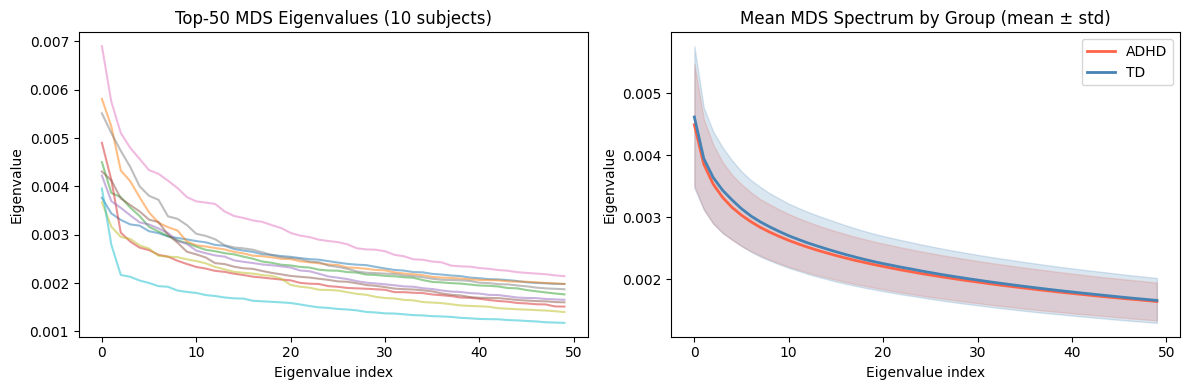

Figure saved to /content/drive/MyDrive/ADHD_Pipeline/figures/mds_spectra.png


In [ ]:
def extract_mds_spectral_features(Omega: np.ndarray, k: int = 50) -> np.ndarray:
    """
    Extract MDS spectral features from resistance distance matrix.

    REVIEWER FIX: These eigenvalues ARE the subject-level feature representation.

    Parameters
    ----------
    Omega : (n_nodes, n_nodes) Resistance distance matrix
    k     : Number of top eigenvalues to retain

    Returns
    -------
    features : (k,) array of top-k eigenvalues (descending order)
    """
    n = Omega.shape[0]

    # Step 1: Double-centering matrix
    H = np.eye(n) - np.ones((n, n)) / n
    Omega_sq = Omega ** 2
    B = -0.5 * H @ Omega_sq @ H

    # Step 2: Eigenvalue decomposition
    eigvals, eigvecs = eigh(B)

    # Step 3: Sort descending and take top-K
    idx_desc = np.argsort(eigvals)[::-1]
    eigvals_desc = eigvals[idx_desc]

    # Keep only positive eigenvalues
    eigvals_desc = np.maximum(eigvals_desc, 0)

    # Return top-K eigenvalues as feature vector
    top_k_eigvals = eigvals_desc[:k]

    # Pad with zeros if fewer than k eigenvalues
    if len(top_k_eigvals) < k:
        top_k_eigvals = np.pad(top_k_eigvals, (0, k - len(top_k_eigvals)))

    return top_k_eigvals


def extract_batch_mds_features(Omega_batch: np.ndarray, k: int = 50) -> np.ndarray:
    """Extract MDS spectral features for a batch of subjects."""
    n_subjects = Omega_batch.shape[0]
    features = np.zeros((n_subjects, k), dtype=np.float32)

    for i in tqdm(range(n_subjects), desc="Extracting MDS features"):
        features[i] = extract_mds_spectral_features(Omega_batch[i], k=k)

    return features


K_MDS = 50
print(f"Extracting MDS spectral features (top-{K_MDS} eigenvalues)...")
print("  REVIEWER NOTE: These eigenvalues ARE the subject-level features")

mds_features_train = extract_batch_mds_features(Omega_train, k=K_MDS)
mds_features_test = extract_batch_mds_features(Omega_test, k=K_MDS)

print(f"\nMDS features shape: {mds_features_train.shape}")
print(f"First 5 eigenvalues for subject 0: {mds_features_train[0, :5]}")

# Visualize eigenvalue spectra
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mds_features_train[:10].T, alpha=0.5)
axes[0].set_xlabel('Eigenvalue index')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title(f'Top-{K_MDS} MDS Eigenvalues (10 subjects)')

# Mean spectrum by group
adhd_idx = np.where(y == 1)[0]
td_idx = np.where(y == 0)[0]

mean_adhd_spectrum = mds_features_train[adhd_idx].mean(axis=0)
mean_td_spectrum = mds_features_train[td_idx].mean(axis=0)
std_adhd_spectrum = mds_features_train[adhd_idx].std(axis=0)
std_td_spectrum = mds_features_train[td_idx].std(axis=0)

axes[1].plot(mean_adhd_spectrum, label='ADHD', color='tomato', linewidth=2)
axes[1].fill_between(range(K_MDS), mean_adhd_spectrum - std_adhd_spectrum,
                     mean_adhd_spectrum + std_adhd_spectrum, alpha=0.2, color='tomato')
axes[1].plot(mean_td_spectrum, label='TD', color='steelblue', linewidth=2)
axes[1].fill_between(range(K_MDS), mean_td_spectrum - std_td_spectrum,
                     mean_td_spectrum + std_td_spectrum, alpha=0.2, color='steelblue')
axes[1].set_xlabel('Eigenvalue index')
axes[1].set_ylabel('Eigenvalue')
axes[1].set_title('Mean MDS Spectrum by Group (mean ± std)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'mds_spectra.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {FIG_DIR / 'mds_spectra.png'}")

In [ ]:
class ResistanceCNN(nn.Module):
    """
    Lightweight CNN for resistance distance matrix classification.

    REVIEWER JUSTIFICATION (Ktena et al., 2018, Medical Image Analysis):
    CNN on symmetric resistance matrix captures local patterns in distance structure.

    Architecture: 3 conv layers (32→64→128) + Global Average Pooling + FC
    """
    def __init__(self, input_size=200, feat_dim=128):
        super(ResistanceCNN, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, feat_dim)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


def train_cnn(Omega_train, y_train, Omega_val, y_val, epochs=30, batch_size=32, lr=1e-4):
    """Train the CNN and return features."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    X_train_tensor = torch.FloatTensor(Omega_train).unsqueeze(1)
    X_val_tensor = torch.FloatTensor(Omega_val).unsqueeze(1)
    y_train_tensor = torch.LongTensor(y_train)
    y_val_tensor = torch.LongTensor(y_val)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = ResistanceCNN(feat_dim=128).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor.to(device))
            val_preds = torch.argmax(val_outputs, dim=1).cpu().numpy()
            val_acc = accuracy_score(y_val, val_preds)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict().copy()

    model.load_state_dict(best_model_state)
    model.eval()

    with torch.no_grad():
        train_features = model(X_train_tensor.to(device)).cpu().numpy()
        val_features = model(X_val_tensor.to(device)).cpu().numpy()

    return train_features, val_features, model, best_val_acc


print("Training CNN on resistance matrices...")
print("  Justification: Ktena et al. (2018) Medical Image Analysis")

# Use first fold for demonstration
with open(FOLD_DIR / 'fold_0.json', 'r') as f:
    fold = json.load(f)

train_idx = fold['train_idx']
val_idx = fold['val_idx']

cnn_train_features, cnn_val_features, cnn_model, val_acc = train_cnn(
    Omega_train[train_idx], y[train_idx],
    Omega_train[val_idx], y[val_idx],
    epochs=30, batch_size=32, lr=1e-4
)

print(f"\nCNN validation accuracy: {val_acc:.4f}")
print(f"CNN features shape: {cnn_train_features.shape}")

torch.save(cnn_model.state_dict(), MODEL_DIR / 'resistance_cnn_fold0.pth')
print(f"Model saved to {MODEL_DIR / 'resistance_cnn_fold0.pth'}")

Training CNN on resistance matrices...
  Justification: Ktena et al. (2018) Medical Image Analysis
